### Decision Tree Regression (회귀 트리)
- 결정 트리와 결정 트리 기반의 앙상블 알고리즘은 분류뿐만 아니라 회귀도 가능하다.
- 분류와 유사하게 분할을 하며, 최종 분할 후 각 분할 영역에서 실제 데이터(타겟)의 평균 값으로 학습 및 예측을 수행한다.

<img src="./images/decision_tree_regression01.png" width="600" style="margin-left: 30px">  

- 회귀 트리 역시 복잡한 트리 구조를 가질 경우 과적합이 위험이 있고, 트리의 크기와 노드의 개수의 제한 등으로 개선할 수 있다.
<img src="./images/decision_tree_regression02.png" width="600" style="margin:20px; margin-left: 0">  

- 독립 변수들과 종속 변수 사이의 관계가 상당히 비선형적일 경우 사용하는 것이 좋다.
<img src="./images/decision_tree_regression03.png" width="800" style="margin:20px; margin-left: 0">
- 하지만 결정 트리 모델은 데이터의 추세를 따라가는 것이 아니라 기존 영역에 가두어 버리기 때문에 새로운 큰 값이 들어오면, 범위 내의 최대 평균값으로 반복해서 예측한다. 또한, 아주 미세한 노이즈까지 학습하기 때문에 데이터의 작은 변화에도 매우 민감하게 반응한다. 따라서 이런 상황에서는 다른 회귀 모델보다 전체적인 성능은 떨어진다.

- 범주형(Categorical) 변수가 많을 때, 독립변수 간 상관관계가 강할 때, 그리고 데이터가 곡선인 경우 사용하는 것이 좋다.

In [32]:
import pandas as pd

c_df = pd.read_csv('./datasets/korea_cow.csv', encoding="euc-kr")
c_df

,일자,번호,출하주,개체번호,성별,kpn,계대,중량,최저가,낙찰가,상태,비고,종류,지역
0,2021.07.23,4,서*호,48928970,암,550.0,3.0,580,360,363,낙찰,목.배밑혹,큰소,경상남도고성
1,2021.07.23,5,이*락,102112702,암,744.0,2.0,460,320,353,낙찰,NaN,큰소,경상남도고성
2,2021.07.23,7,문*종,156144852,암,1263.0,4.0,340,400,471,낙찰,목이모색 상처,큰소,경상남도고성
3,2021.07.23,8,문*종,136983661,암,1159.0,2.0,380,400,432,낙찰,뒷다리약간절음,큰소,경상남도고성
4,2021.07.23,9,이*만,138655532,암,1124.0,6.0,550,650,766,낙찰,NaN,큰소,경상남도고성
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19976,2021.06.22,320,윤*식,157190517,암,0.0,1.0,0,390,0,유찰,NaN,혈통우,전라남도 함평
19977,2021.06.22,321,윤*식,154652064,암,0.0,1.0,0,430,0,유찰,NaN,혈통우,전라남도 함평
19978,2021.06.22,322,윤*식,156278395,암,0.0,1.0,0,450,0,유찰,NaN,혈통우,전라남도 함평
19979,2021.06.22,323,윤*식,155232402,암,0.0,1.0,0,460,530,낙찰,정영기 -> 박손엽,혈통우,전라남도 함평


In [33]:
c_df.columns

Index(['일자', '번호', '출하주', '개체번호', '성별', 'kpn', '계대', '중량', '최저가', '낙찰가', '상태',
       '비고', '종류', '지역'],
      dtype='object')

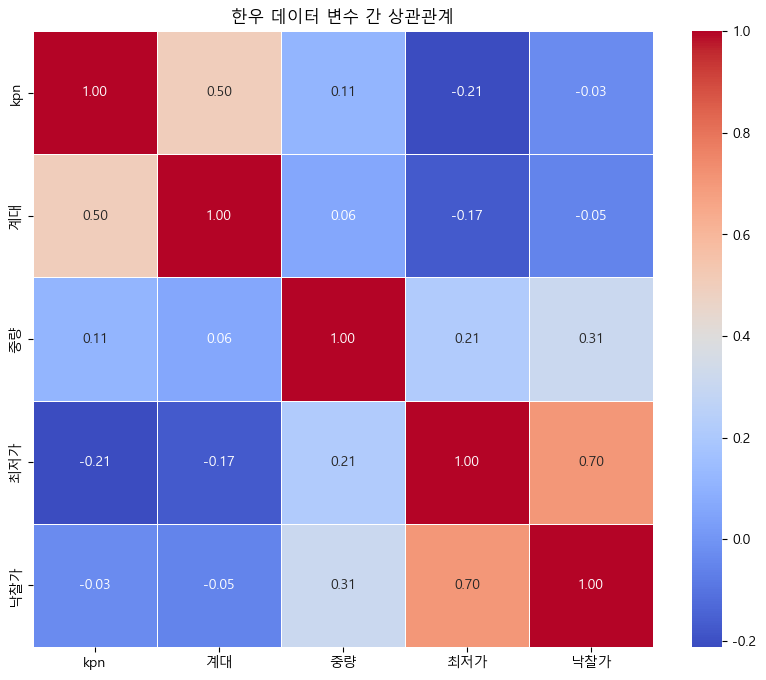

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

corr = c_df[['kpn', '계대', '중량', '최저가', '낙찰가']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("한우 데이터 변수 간 상관관계")
plt.show()

In [35]:
c_df.isna().sum()

일자          0
번호          0
출하주        34
개체번호        0
성별          1
kpn        10
계대         10
중량          0
최저가         0
낙찰가         0
상태          0
비고      12319
종류          0
지역          0
dtype: int64

In [36]:
c_df = c_df.drop(columns=['개체번호', '출하주', 'kpn', '비고', '일자', '번호', '지역'])
c_df.isna().sum()

성별      1
계대     10
중량      0
최저가     0
낙찰가     0
상태      0
종류      0
dtype: int64

In [37]:
c_df= c_df[~c_df.성별.isna()]
c_df= c_df[~c_df.계대.isna()]
c_df.isna().sum()

성별     0
계대     0
중량     0
최저가    0
낙찰가    0
상태     0
종류     0
dtype: int64

In [38]:
c_df.duplicated().sum()

np.int64(4015)

In [39]:
c_df.drop_duplicates(ignore_index=True, inplace=True)
c_df

,성별,계대,중량,최저가,낙찰가,상태,종류
0,암,3.0,580,360,363,낙찰,큰소
1,암,2.0,460,320,353,낙찰,큰소
2,암,4.0,340,400,471,낙찰,큰소
3,암,2.0,380,400,432,낙찰,큰소
4,암,6.0,550,650,766,낙찰,큰소
...,...,...,...,...,...,...,...
15951,수,1.0,0,380,477,낙찰,혈통우
15952,암,1.0,0,400,484,낙찰,혈통우
15953,암,1.0,0,430,451,낙찰,혈통우
15954,암,1.0,0,460,530,낙찰,혈통우


In [40]:
c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15956 entries, 0 to 15955
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   성별      15956 non-null  object 
 1   계대      15956 non-null  float64
 2   중량      15956 non-null  int64  
 3   최저가     15956 non-null  int64  
 4   낙찰가     15956 non-null  int64  
 5   상태      15956 non-null  object 
 6   종류      15956 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 872.7+ KB


In [41]:
c_df.상태.value_counts()

상태
낙찰    15248
유찰      488
대기      219
보류        1
Name: count, dtype: int64

In [42]:
c_df = c_df[c_df.상태 == '낙찰']
c_df

,성별,계대,중량,최저가,낙찰가,상태,종류
0,암,3.0,580,360,363,낙찰,큰소
1,암,2.0,460,320,353,낙찰,큰소
2,암,4.0,340,400,471,낙찰,큰소
3,암,2.0,380,400,432,낙찰,큰소
4,암,6.0,550,650,766,낙찰,큰소
...,...,...,...,...,...,...,...
15951,수,1.0,0,380,477,낙찰,혈통우
15952,암,1.0,0,400,484,낙찰,혈통우
15953,암,1.0,0,430,451,낙찰,혈통우
15954,암,1.0,0,460,530,낙찰,혈통우


In [43]:
c_df.drop(['상태'], axis=1, inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14488\2039432905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df.drop(['상태'], axis=1, inplace=True)


In [44]:
c_df.성별.value_counts()

성별
수     8233
암     6889
거세     116
프       10
Name: count, dtype: int64

In [45]:
condition1 = c_df.성별 == '수'
condition2 = c_df.성별 == '암'
condition = condition1 | condition2

c_df[condition].성별.value_counts()
c_df = c_df[condition]

In [46]:
c_df.종류.value_counts()

종류
혈통우    10610
큰소      4512
Name: count, dtype: int64

In [47]:
c_df.describe().T

,count,mean,std,min,25%,50%,75%,max
계대,15122.0,3.498744,2.057189,0.0,2.0,3.0,5.0,15.0
중량,15122.0,142.252083,187.357337,0.0,0.0,0.0,250.0,850.0
최저가,15122.0,428.504894,107.785201,0.0,360.0,420.0,470.0,1150.0
낙찰가,15122.0,486.605806,120.155980,55.0,408.0,473.0,546.0,1229.0


In [48]:
c_df = c_df[c_df.중량 != 0]
c_df.describe().T

,count,mean,std,min,25%,50%,75%,max
계대,6981.0,3.823091,1.868243,0.0,3.0,4.0,5.0,13.0
중량,6981.0,308.141527,157.859180,1.0,230.0,260.0,430.0,850.0
최저가,6981.0,425.481736,102.045238,0.0,350.0,420.0,480.0,950.0
낙찰가,6981.0,494.443203,118.278328,61.0,412.0,489.0,560.0,1170.0


In [49]:
c_df = c_df[c_df.계대 != 0]
c_df = c_df[c_df.최저가 != 0]
c_df.reset_index(drop=True, inplace=True)
c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6866 entries, 0 to 6865
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   성별      6866 non-null   object 
 1   계대      6866 non-null   float64
 2   중량      6866 non-null   int64  
 3   최저가     6866 non-null   int64  
 4   낙찰가     6866 non-null   int64  
 5   종류      6866 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 322.0+ KB


In [50]:
c_df.dtypes

성별      object
계대     float64
중량       int64
최저가      int64
낙찰가      int64
종류      object
dtype: object

In [51]:
c_df.dtypes == 'O'

성별      True
계대     False
중량     False
최저가    False
낙찰가    False
종류      True
dtype: bool

In [52]:
from sklearn.preprocessing import LabelEncoder

encoder_list = []

for column in c_df.columns[c_df.dtypes == 'O']:
    encoder = LabelEncoder()
    c_df[column] = encoder.fit_transform(c_df[column])
    encoder_list.append(encoder)
    print(encoder.classes_)

['수' '암']
['큰소' '혈통우']


In [53]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [56]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

feature, target = c_df.drop('낙찰가', axis=1), c_df.낙찰가
poly_features = PolynomialFeatures(degree=3).fit_transform(feature.values)

X_train, X_test, y_train, y_test = \
train_test_split(poly_features, target, test_size=0.2, random_state=124)

In [58]:
%pip install xgboost lightgbm

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   -------------------- ------------------- 1/2 [lightgbm]
   ---------------------------------------- 2/2 [lightgbm]

Note: you may need to restart the kernel to use updated packages.


In [59]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=4)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=1000, max_depth=8)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=1000, max_depth=8)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=8)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=8)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, prediction)

DecisionTreeRegressor
MAE: 33.2299, MSE: 1857.6863, RMSE: 43.1009, MSLE: 0.0082, RMSLE: 0.0904, R2: 0.8672
RandomForestRegressor
MAE: 29.6492, MSE: 1522.2801, RMSE: 39.0164, MSLE: 0.0062, RMSLE: 0.0786, R2: 0.8912
GradientBoostingRegressor
MAE: 33.6557, MSE: 1926.1352, RMSE: 43.8878, MSLE: 0.0081, RMSLE: 0.0899, R2: 0.8623
XGBRegressor
MAE: 34.4589, MSE: 1987.2788, RMSE: 44.5789, MSLE: 0.0084, RMSLE: 0.0914, R2: 0.8579
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5291
[LightGBM] [Info] Number of data points in the train set: 5492, number of used features: 55
[LightGBM] [Info] Start training from score 495.085761
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

C:\ProgramData\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
